# Comportamento de Compras na Instacart

# Introdução

O Instacart é uma plataforma de entrega de supermercado, em que o cliente faz o pedido pelo aplicativo e recebe a compra em casa, em um modelo parecido com o do iFood e do Uber Eats.

Esta análise usa uma versão reduzida do conjunto de dados original, preparada com valores ausentes e duplicados propositais para exercitar o tratamento de dados, preservando as distribuições da base completa. O trabalho está dividido em visão geral dos dados, preparação e análise exploratória dos hábitos de compra.

## Dicionário de dados

O conjunto de dados tem cinco tabelas, descritas abaixo com as colunas de cada uma.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento

# Visão geral dos dados

## Plano de solução

Meu plano para visão geral dos dados envolve importar os dados e utilizar métodos para me familiarizar com eles como .info() .head() e .shape(). Com essas informações fornecendo uma compreensão melhor dos dados posso tomar decisões à respeito de como manipular os dados para análise

In [9]:
# Importe as bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# leia os conjuntos de dados em DataFrames
# Importar os dataframes individualmente, dessa forma podemos manipular melhor os dados,
# se necessário podemos fazer as junções com merge() ou concat().
instacart_orders = pd.read_csv('/datasets/instacart_orders.csv',sep=';')
products = pd.read_csv('/datasets/products.csv',sep=';')
aisles = pd.read_csv('/datasets/aisles.csv',sep=';')
departments = pd.read_csv('/datasets/departments.csv',sep=';')
order_products = pd.read_csv('/datasets/order_products.csv',sep=';')

In [11]:
print(instacart_orders.info())
# O dataframe utiliza '; como separador', é composto pór 6 colunas e 478967 linhas. 
#A coluna days_since_prior_order tem alguns valores nulos e está no tipo float,as outras colunas estão completas e contém dados do tipo int.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [12]:
print(products.info())
# O dataframe utiliza ';' como separador, é composto por 4 colunas e 49694 linhas.
# A coluna product_name chama atenção, tem valores nulos e os dados são objetos, as outras colunas estão completas e seus dados são tipo int.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [13]:
print(aisles.info())
# O dataframe utiliza ';' como separador, é composto por 2 colunas e 134 linhas.
# As 2 colunas do dataframe estão completas,sem valores nulos. A coluna aisle_id é composta por dados int, a coluna aisle por dados objetos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [14]:
print(departments.info())
# O dataframe utiliza ';' como separador, é composto por 2 colunas e 21 linhas.
# As 2 colunas do dataframe estão completas,sem valores nulos. A coluna department_id é composta por dados int, a coluna department por dados objetos.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


In [15]:
print(order_products.info())
# O dataframe utiliza ';' como separador, é composto por 4 colunas e 4545007 linhas.
# O data frame contém 4 colunas,a informação sobre os valores não-nulos foi omitida.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


## Conclusões

Os dataframes são longos, possuem poucas colunas e muitas linhas. Estão consideravelmente completos, visto que, com exceção do último dataframe que os valores não nulos estão omitidos, apresentam no máximo 1 coluna com valores nulos, e a maioria dos valores dessa única coluna são não-nulos.

# Preparação dos dados

## Plano de solução

Meu plano para a preparação de dados é lidar com valores ausentes e duplicados utilizando dos métodos necessários. Primeiro identificar pedidos duplicados e nulos em cada um dos dataframes, em seguida avaliar se os valores devem ser removidos.

## Valores duplicados

### DataFrame `instacart_orders`

In [16]:
# Verificar se há pedidos duplicados
instacart_orders.duplicated().sum()
# O método informou que existem 15 linhas duplicadas,então vamos verificar essas linhas.
instacart_orders[instacart_orders.duplicated()]

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Há linhas duplicadas? Se sim, o que elas têm em comum?

Sim, há linhas duplicadas. Elas tem em comum o dia da semana e a hora do dia. Todos ocorreram no dia 3(considerando domingo como 0 é uma Quarta-feira), na hora 2.

In [17]:
# Com base nas suas conclusões,

# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras
pedidos_quarta_2horas = instacart_orders[(instacart_orders['order_dow'] == 3) & (instacart_orders['order_hour_of_day'] == 2)]
#investigando o df resultante
print(pedidos_quarta_2horas.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 121 entries, 4838 to 477526
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                121 non-null    int64  
 1   user_id                 121 non-null    int64  
 2   order_number            121 non-null    int64  
 3   order_dow               121 non-null    int64  
 4   order_hour_of_day       121 non-null    int64  
 5   days_since_prior_order  114 non-null    float64
dtypes: float64(1), int64(5)
memory usage: 6.6 KB
None


O que esse resultado quer dizer?
 
 Esse resultado mostra que existem 121 pedidos ás 2h da manhã da quarta-feira, então houveram pedidos nessa mesma janela de horários que ocorreram normalmente. Isso pode dizer que talvez tenha dado um erro em um pequeno período nessa janela de 1h, ou que talvez o sistema estivesse funcionando normalmente e seja algo com usuários ou pedidos específicos

In [67]:
# Remova pedidos duplicados
# Guardar as linhas duplicadas,pois sei que usarei no próximo passo
linhas_duplicadas = instacart_orders[instacart_orders.duplicated(keep=False)]
instacart_orders = instacart_orders.drop_duplicates().reset_index(drop=True)
pedidos_quarta_2horas = pedidos_quarta_2horas.drop_duplicates().reset_index(drop=True)

In [68]:
# Verifique as linhas duplicadas mais uma vez
instacart_orders.duplicated().sum()
pedidos_quarta_2horas.duplicated().sum()

0

In [20]:
# Verifique novamente apenas os IDs de pedidos duplicados
print(f"Número de pedidos quarta-feira 2horas da manhã: {len(pedidos_quarta_2horas)}")
print(f"Número de order_ids únicos nas linhas duplicadas: {linhas_duplicadas['order_id'].nunique()}")
print(f"Número de user_ids únicos nas linhas duplicadas: {linhas_duplicadas['user_id'].nunique()}")

Número de pedidos quarta-feira 2horas da manhã: 106
Número de order_ids únicos nas linhas duplicadas: 15
Número de user_ids únicos nas linhas duplicadas: 15


**Conclusões**

Foram identificadas 15 linhas duplicadas no dataframe instacart_orders. Todas as duplicatas ocorreram na quarta-feira (dia 3) às 2h da manhã. Nessa janela, ocorreram 121 pedidos totais,e cada pedido duplicado possui order_id único e user_id único, indicando que não se trata de erro de usuário específico.A concentração temporal das duplicatas sugere uma falha momentânea no sistema durante esse período específico. As linhas duplicadas foram removidas usando drop_duplicates(), pois representam registros errôneos que poderiam distorcer as análises posteriores. No entanto, ainda é necessário analisar se existe algo em comum nesses pedidos, pois instacart_order não oferece informações sobre os produtos nos pedidos.

### DataFrame `products`

In [21]:
# Verifique se há linhas completamente duplicadas
products.duplicated().sum()

0

In [22]:
# Verifique apenas IDs dos produtos duplicados
products['product_id'].duplicated().sum()

0

In [23]:
# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
products['product_name'] = products['product_name'].str.lower()
products['product_name'].duplicated().sum()

1361

In [24]:
# Verifique os nomes de produtos duplicados que não estão faltando
produtos_duplicados = products[products['product_name'].notna() & products['product_name'].duplicated()]
produtos_duplicados.duplicated().sum()

0

**Conclusões**

O dataframe products nãotem linhas completamente duplicadas,o método duplicated() associado com o método sum(), demonstram isso. Verificando apenas os IDs dos produtos, podemos ver também que não existem IDs de produtos duplicados. Convertendo a coluna 'product_name' para caixa baixa, para padronizar o texto e permitir uma comparação melhor, encontramos 1361 nomes de produtos duplicados, mas ao pesquisar os produtos duplicados sem valores faltando, percebemos que não temos mais duplicados. Dessa forma, podemos concluir que os valores ausentes estão causando duplicações na coluna 'product_name'.

### DataFrame `departments`

In [25]:
# Verifique se há linhas completamente duplicadas
departments.duplicated().sum()

0

In [26]:
# Verifique apenas IDs duplicados de departamentos
departments['department_id'].duplicated().sum()

0

**Conclusões**

 Utilizando os métodos em conjuntos no dataframe departments, podemos verificar que não existem linhas completamente duplicadas. Ademais, aplicando esses mesmos métodos somente à coluna department_id, confirmamos que não temos IDs de departamentos duplicados.

### DataFrame `aisles`

In [27]:
# Verifique se há linhas completamente duplicadas
aisles.duplicated().sum()

0

In [28]:
# Verifique apenas IDs duplicados de corredores
aisles['aisle_id'].duplicated().sum()

0

**Conclusões**

 Utilizando os métodos em conjuntos no dataframe aisles, podemos verificar que não existem linhas completamente duplicadas. Ademais, aplicando esses mesmos métodos somente à aisle_id, confirmamos que não temos IDs de corredores duplicados.

### DataFrame `order_products`

In [29]:
# Verifique se há linhas completamente duplicadas
order_products.duplicated().sum()

0

In [30]:
# Verifique mais uma vez se há outros casos complicados de duplicados
duplicatas_problematicas = order_products.duplicated(subset=['order_id', 'product_id']).sum()
print(f"Duplicatas problemáticas (mesmo produto no mesmo pedido): {duplicatas_problematicas}")

Duplicatas problemáticas (mesmo produto no mesmo pedido): 0


**Conclusões**

O dataframe order_products não tem linhas completamente duplicadas. Por garantia, investiguei casos complicados,esses casos seriam pedidos com order_id e product_id repetidos. Isso ocorre pois se o pedido tiver vários produtos o order_id vai se repetir, e um produto product_id pode ser comprado várias vezes. Dessa forma os únicos duplicados problemáticos seriam quando um mesmo order_id com os mesmos product_id, pois indica que um mesmo pedido com os mesmos produtos ocorreu.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [31]:
# Encontre valores ausentes na coluna 'product_name'
products['product_name'].isna().sum()

1258

**Conclusões**

Existem 1258 valores ausentes na coluna 'product_name' do dataframe products

In [32]:
# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?
product_name_nan = products[products['product_name'].isna()]
product_name_nan.groupby('aisle_id').count()

,product_id,product_name,department_id
aisle_id,,,
100,1258,0,1258


**Conclusões**

Sim, todos os valores ausentes estão associados com o corredor de ID 100.

In [33]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
product_name_nan.groupby('department_id').count()

,product_id,product_name,aisle_id
department_id,,,
21,1258,0,1258


**Conclusões**

Sim, todas os nomes de produtos ausentes estão associados com o departamento de ID 21.

In [34]:
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.
print(departments[departments['department_id'] == 21])
print(aisles[aisles['aisle_id'] == 100])

    department_id department
20             21    missing
    aisle_id    aisle
99       100  missing


**Conclusões**

O departamento de ID 21 está faltando,assim como o corredor de ID 100.

In [35]:
# Preencha nomes de produtos ausentes com 'Unknown'
# Utilizando inplace = True pois quero modificar o dataframe original, não criar uma cópia.
products['product_name'].fillna('Unknown', inplace=True)
# Verificando se a modificação foi bem sucedida
products['product_name'].isna().sum()

0

**Conclusões**

Investigando os valores ausentes identificamos que o departamento de ID 21 está faltando, gerando valores ausentes. O mesmo o correu com o corredor de ID 100. Como consequência a coluna 'product_name' do dataframe products estava faltando 1258 valores,esses valores foram substituídos por 'Unknown'.

### DataFrame `orders`

In [36]:
#Instaccart_orders
# Encontre os valores ausentes
instacart_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [37]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
clientes_reincidentes = instacart_orders[(instacart_orders['order_number'] > 1)]
clientes_reincidentes['days_since_prior_order'].isna().sum()

0

**Conclusões**

Existem 28817 valores ausentes no dataframe instacart_orders, todos esses valores se encontram na coluna days_since_prior_order. São esperados valores ausentes nessa coluna, pois clientes realizando o primeiro pedido não realizaram um pedido anterior. Filtrando o dataframe pra clientes reincidentes verificamos que não existem valores ausentes na coluna. Isso significa que os valores ausentes são, exclusivamente, de clientes novos. Dessa forma podemos concluir que os dados estão preparados.

### DataFrame `order_products`

In [38]:
# Encontre os valores ausentes
order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [39]:
# Quais são os valores mínimo e máximo dessa coluna?
print(f"Valor mínimo: {order_products['add_to_cart_order'].min()}")
print(f"Valor máximo: {order_products['add_to_cart_order'].max()}")

Valor mínimo: 1.0
Valor máximo: 64.0


O dataframe order_products apresenta 836 valores ausentes, todos esses valores estão na coluna 'add_to_cart'. Os valores nessa coluna indicam que o pedido mínimo teve 1 produto, e o máximo 64 produtos.

In [40]:
# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'
# Criando um dataframe com os pedidos com valores ausentes.
pedidos_com_valores_ausentes = order_products[order_products['add_to_cart_order'].isna()]
print(pedidos_com_valores_ausentes)

         order_id  product_id  add_to_cart_order  reordered
737       2449164        5068                NaN          0
9926      1968313       43867                NaN          0
14394     2926893       11688                NaN          0
16418     1717990        4142                NaN          0
30114     1959075       42828                NaN          1
...           ...         ...                ...        ...
4505662   1800005        7411                NaN          0
4511400   1633337         260                NaN          0
4517562    404157        9517                NaN          0
4534112   1673227       17835                NaN          0
4535739   1832957       17949                NaN          1

[836 rows x 4 columns]


In [41]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
produtos_por_pedido_NaN = pedidos_com_valores_ausentes.groupby('order_id')['product_id'].count().reset_index()
# Definindo nome das colunas pra melhorar a legibilidade
produtos_por_pedido_NaN.columns = ['order_id', 'product_count']
print(produtos_por_pedido_NaN.head(5))
# Agrupe os pedidos com dados ausentes por ID de pedido
print(f"ID dos pedidos com valores ausentes (primeiros 5) : \n{pedidos_com_valores_ausentes['order_id'].unique()[:5]}")
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
print(f"Valor mínimo de product_id em cada pedido: { produtos_por_pedido_NaN.min()}")

   order_id  product_count
0      9310              1
1     61355             63
2    102236             31
3    129627              5
4    165801              6
ID dos pedidos com valores ausentes (primeiros 5) : 
[2449164 1968313 2926893 1717990 1959075]
Valor mínimo de product_id em cada pedido: order_id         9310
product_count       1
dtype: int64


**Conclusões**

Não, nem todos os pedidos com valores ausentes contêm mais de 64 produtos. Contando os product_id em cada um dos 70 pedidos com valores ausentes podemos verificar que existem pedidos com 1 produto (valor mínimo), com valores ausentes.

In [42]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999).astype(int)

**Conclusões**

A ordem dos produtos no carrinho deveria ser número inteiros. A coluna anteriormente estava como float devido aos valores ausentes,ao converter os valores NaN(float) em 999 podemos ajustar a coluna para números inteiros, facilitando a análise.

## Conclusões

    A preparação de dados na etapa 2 ocorreu, principalmente, lidando com valores duplicados e valores ausentes. Ao explorar os dados podemos perceber que na quarta-feira às 2h da manhã alguns pedidos foram duplicados, o que sugere uma falha técnica no período. No entanto, nessa mesma janela tivemos pedidos concluídos normalmente, isso indica que a falha pode ter sido temporária, e não durante a janela completa. Outro fatores importantes que devem ser investigados são a falta de valores no departamento de ID 21 e no corredor de ID 100. Essas ausências explicam os valores ausentes na coluna 'product_name',que foram substituídos por 'Unknown'. Por fim, alguns pedidos tiveram valores ausentes na coluna 'add_to_cart_order', que estava como float. Essa descoberta sugere que o carrinho está apresentando problemas na ordenação dos pedidos, principalmente ao analisarmos que pedidos de clientes que já realizaram pedidos anteriormente tiveram esse problema. Nesse contexto convertemos os valores da coluna 'add_to_cart_orders' para int,e substituímos os valores ausentes por 999, dessa forma os valores ausentes não comprometem o restante dos dados.

    Resumo em tópicos:
        Problemas identificados:
        - Duplicatas: 15 pedidos duplicados na quarta-feira às 2h
        - Valores ausentes: departamento ID 21 e corredor ID 100 faltantes
        - Problemas no carrinho: 836 valores ausentes em add_to_cart_order

        Soluções aplicadas:
        - Remoção de duplicatas para evitar distorções
        - Substituição de product_name ausentes por 'Unknown'
        - Conversão de add_to_cart_order para int com valor 999 para ausentes

# Análise de dados

### Consistência dos valores de hora e dia da semana

In [43]:
print(instacart_orders['order_hour_of_day'].describe())

count    478952.000000
mean         13.447034
std           4.224567
min           0.000000
25%          10.000000
50%          13.000000
75%          16.000000
max          23.000000
Name: order_hour_of_day, dtype: float64


In [44]:
print(instacart_orders['order_dow'].describe())

count    478952.000000
mean          2.775051
std           2.045901
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: order_dow, dtype: float64


Escreva suas conclusões aqui

Os valores fazem sentido, os valores na coluna order_hour_of_day indicam um alcance de 0 a 23, e os valores da coluna order_dow indicam um alcance de 0 a 6.

### Pedidos por hora do dia

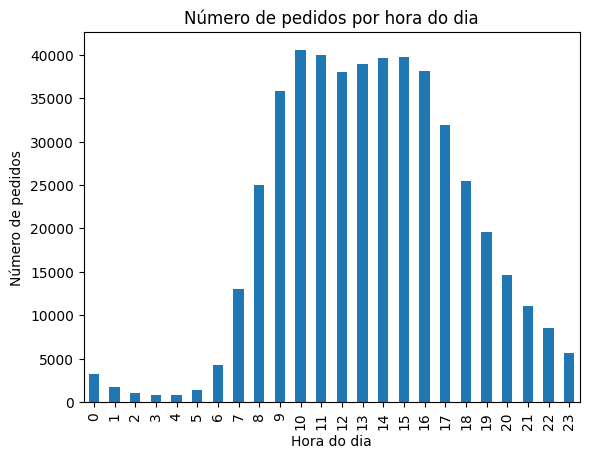

In [45]:
instacart_orders['order_hour_of_day'].value_counts().sort_index().plot(kind='bar')
plt.title('Número de pedidos por hora do dia')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.show()

As pessoas fazem mais pedidos no período entre as 9h e 17h com máxima as 10h. A mínima acontece durante a madrugada entre 2h e 5h da manhã.

### Pedidos por dia da semana

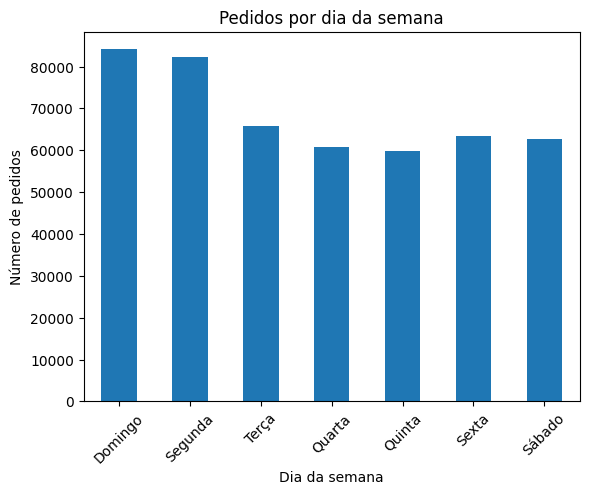

In [46]:
# Criar a lista dos dias da semana
dias_semana = ['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado']
pedidos_por_dia = instacart_orders['order_dow'].value_counts().sort_index()
pedidos_por_dia.index = dias_semana
pedidos_por_dia.plot(kind='bar')
plt.title('Pedidos por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.show()

In [47]:
print(departments['department'])

0              frozen
1               other
2              bakery
3             produce
4             alcohol
5       international
6           beverages
7                pets
8     dry goods pasta
9                bulk
10      personal care
11       meat seafood
12             pantry
13          breakfast
14       canned goods
15         dairy eggs
16          household
17             babies
18             snacks
19               deli
20            missing
Name: department, dtype: object


Através do gráfico podemos analisar que os dias da semana em que as pessoas mais compram produtos são aos Domingos e Segundas. Esses dias se destacam no número de pedidos, enquanto de Terça à Sábado os pedidos se apresentam de forma constante.

### Intervalo entre pedidos

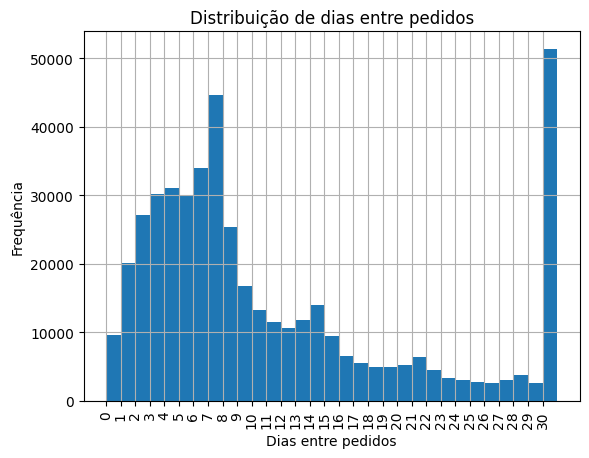

In [48]:
instacart_orders['days_since_prior_order'].hist(bins=range(0,32))
plt.title('Distribuição de dias entre pedidos')
plt.xlabel('Dias entre pedidos')
plt.xticks(range(0, 31))
plt.xticks(rotation=90)
plt.ylabel('Frequência')
plt.show()

    Os números de dias mais comuns entre pedidos são 7 e principalmente 30dias. Essa distribuição pode explicar que os usuários mantém hábitos de compras semanais e mensais.Essa análise faz bastante sentido considerando que uma boa parte dos departamentos são produtos alimentícios. Ainda é válidos avaliar que o número de pedidos no período até 7 dias é consideravelmente maior que após o sétimo dia(com excessão do intervalo de exatamente 30dias). Essa preferência por intervalos mais curtos nos dias de compras pode indicar que os usuários preferem compras frequentes ou mantém o hábito de fazer compras na plataforma.

Destaques:
   
    Picos em 7 e 30 dias, indicam padrões comportamentais.
    Maior frequência até 7 dias comparando com após esse período.
    
Propostas:

    Programa de fidelidade anual,aproveita o padrão mensal e incentiva compras maiores.
    
    Ofertas semanais,alinha perfeitamente com o pico de 7 dias
    
    Dairy Day(no dia que os produtos derivados do leite chegassem a loja) incentivando a compra do produto fresco e com desconto),
              conectando produtos frescos(qualidade),com o hábito de compras.

### Distribuição por hora nas quartas e nos sábados

In [49]:
#Contando pedidos por hora para quartas e sábados
quartas_por_hora = instacart_orders[instacart_orders['order_dow'] == 3]['order_hour_of_day'].value_counts().sort_index()
sabados_por_hora = instacart_orders[instacart_orders['order_dow'] == 6]['order_hour_of_day'].value_counts().sort_index()

In [50]:
# Criar um DataFrame com ambos os dias
dados_comparacao = pd.DataFrame({
    'Quartas': quartas_por_hora,
    'Sábados': sabados_por_hora})

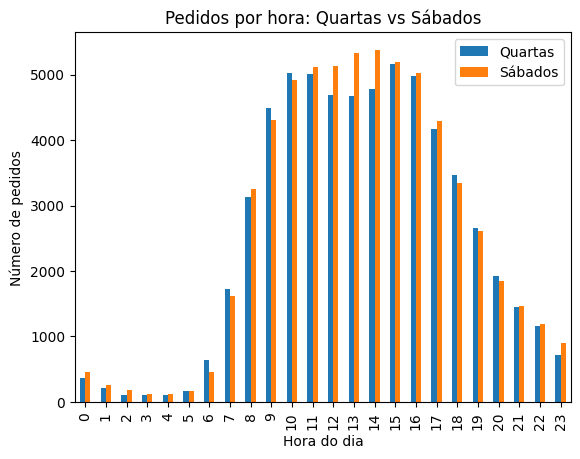

In [51]:
dados_comparacao.plot(kind='bar')
plt.title('Pedidos por hora: Quartas vs Sábados')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.legend()
plt.show()

    Analisando o gráfico podemos perceber comportamentos parecidos durante as compras nas Quartas comparando as compras nos Sábados. No geral as compras começam o dia em baixa e apresentam um crescimento consideravel das 6h às 10h da manhã. O número de pedidos voltam a cair as 15h. Os pedidos as quartas vencem o número de pedidos aos Sábados de manhã cedo, das 6h da manhã até as 10h da manhã e no fim do dia, das 18h às 20h da noite. Essa relação ocorre, provavelmente, devido a jornada de trabalho. Como quarta é um dia útil é normal imaginar que as compras ocorram antes ou depois da jornada de trabalho, justificando os números superiores nesses horários. O pico de pedidos nos sábados ocorrem durante a tarde, na janela das 14h. 

### Distribuição do número de pedidos por cliente

In [52]:
min_pedidos = instacart_orders['order_number'].min()
max_pedidos = instacart_orders['order_number'].max()
print(f"Mínimo: {min_pedidos}, Máximo: {max_pedidos}")

Mínimo: 1, Máximo: 100


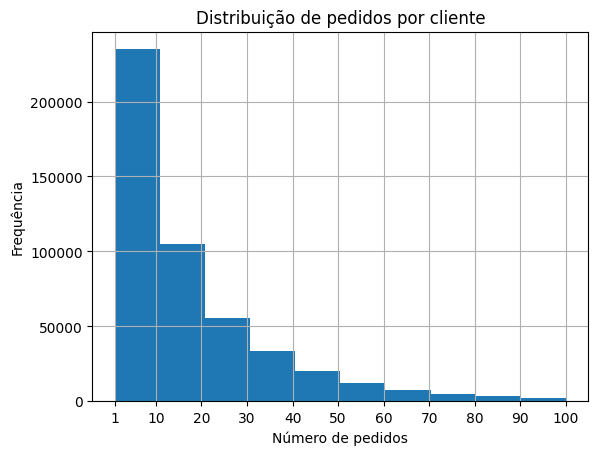

In [53]:
instacart_orders['order_number'].hist(range=(min_pedidos, max_pedidos))
plt.xticks([min_pedidos] + list(range(10, 101, 10)))
plt.title('Distribuição de pedidos por cliente')
plt.xlabel('Número de pedidos')
plt.ylabel('Frequência')
plt.show()

Podemos concluir que a distribuição de pedidos por cliente tende a diminuir com o aumento do número de pedidos, o que é esperado. Essa situação reforça a proposta de implementar um plano de fidelidade.

### Os 20 produtos mais populares

In [54]:
# Buscando os produtos populares por contagem de product_id (produtos) no dataframe order_products(pedidos) ordenando do mais popular
produtos_populares = order_products.groupby('product_id')['order_id'].count().sort_values(ascending = False)
# Filtrando os 20 mais populares
top20_produtos = produtos_populares.head(20)
# Transformando top20_produtos em um dataframe pra facilitar a junção.
# A junção é necessária pois os nomes estão em um dataframe diferente (products)
top20_produtos_df = top20_produtos.reset_index()

In [55]:
# Juntando o dataframe top20_produtos com o dataframe products(produtos) par obter a informação completa
top20_completo = top20_produtos_df.merge(products, on='product_id')

In [56]:
print(top20_completo[['product_id', 'product_name']])

    product_id              product_name
0        24852                    banana
1        13176    bag of organic bananas
2        21137      organic strawberries
3        21903      organic baby spinach
4        47209      organic hass avocado
5        47766           organic avocado
6        47626               large lemon
7        16797              strawberries
8        26209                     limes
9        27845        organic whole milk
10       27966       organic raspberries
11       22935      organic yellow onion
12       24964            organic garlic
13       45007          organic zucchini
14       39275       organic blueberries
15       49683            cucumber kirby
16       28204        organic fuji apple
17        5876             organic lemon
18        8277  apple honeycrisp organic
19       40706    organic grape tomatoes


    Os usuários do instacart valorizam produtos orgânicos, 15 dos 20 produtos mais comprados tem orgânico no nome.
    Os usuários do instacart gostam de pedir frutas, 8 entre os 10 produtos mais populares são frutas, a lista total dos 20 mais populares tem 13 frutas. 
    Conclusões:
        Os usuários da instacart valorizam produtos orgânicos, isso pode indicar que os usuários valorizam hábitos saudáveis. Investir em produtos saudáveis pode ter uma boa resposta dos clientes.
        Frutas são alimentos que dependem do frescor e da conservação, ter 13 frutas entre os 20 produtos mais populares indica que o sistema delivery está funcionando adequadamente. Isso gera uma dúvida, a instacart oferece um departamento de Congelados, e tem um sistema delivery eficiente. A falta de produtos desse departamento pode indicar que os usuários não tenham interesse no departamento ou a qualidade dos produtos do departamento não está satisfatória.
        Ainda nesse contexto, é válido destacar a banana, essa fruta ocupa as 2 primeiras posições na lista de top20 produtos, possivelmente investir em mais variedades dessa fruta pode trazer bons resultados. Considerando que é uma fruta prática, versátil e pronta para consumo, isso pode ser exatamente o que atrai os usuários para o serviço,justificando o seu sucesso.
        Essas informações orientam a seleção de fornecedores estratégicos, priorizando parcerias com produtores de alimentos orgânicos e sistemas de distribuição que garantam o frescor dos produtos.

### Quantidade de itens por pedido

In [57]:
# Encontrando o número de produtos por pedidos
produtos_por_pedido = order_products.groupby('order_id')['add_to_cart_order'].count()

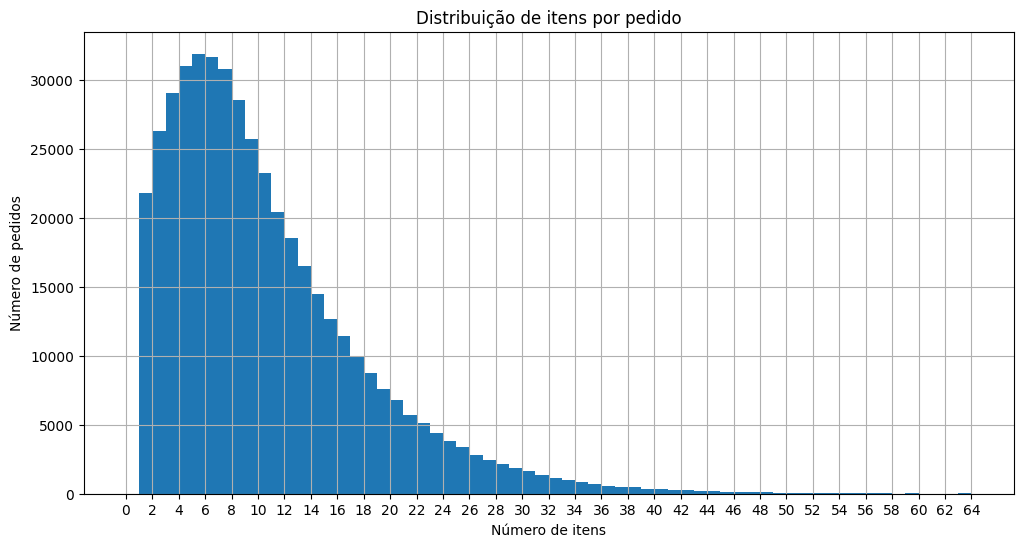

In [58]:
plt.figure(figsize=(12, 6))
produtos_por_pedido.hist(bins=range(0,65,1))
plt.xticks(range(0,65,2))
plt.title('Distribuição de itens por pedido')
plt.xlabel('Número de itens')
plt.ylabel('Número de pedidos')
plt.show()

In [59]:
produtos_por_pedido.describe()

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: add_to_cart_order, dtype: float64

    Através do histograma podemos perceber que a maioria dos pedidos se concentram na margem de 4 a 8 itens. Isso faz sentido considerando que avaliamos comportamento dos clientes com compras semanais e mensais,onde compras semanais tendem a ter menos itens e mais frequência. Essa análise também justificaria porque que pedidos com 1 e 2 itens não são tão populares e a distribuição é controlada com número de pedidos maiores.

### Os 20 itens mais frequentes em pedidos repetidos

In [60]:
produtos_repetidos = order_products[(order_products['reordered']== 1)]

In [61]:
produtos_repetidos = produtos_repetidos.groupby('product_id')['order_id'].count().sort_values(ascending = False)
top20_repetidos = produtos_repetidos.head(20)
top20_repetidos = top20_repetidos.reset_index()

In [62]:
top20_repetidos_completo = top20_repetidos.merge(products,on='product_id')

In [63]:
print(top20_repetidos_completo[['product_id', 'product_name']])

    product_id              product_name
0        24852                    banana
1        13176    bag of organic bananas
2        21137      organic strawberries
3        21903      organic baby spinach
4        47209      organic hass avocado
5        47766           organic avocado
6        27845        organic whole milk
7        47626               large lemon
8        27966       organic raspberries
9        16797              strawberries
10       26209                     limes
11       22935      organic yellow onion
12       24964            organic garlic
13       45007          organic zucchini
14       49683            cucumber kirby
15       28204        organic fuji apple
16        8277  apple honeycrisp organic
17       39275       organic blueberries
18        5876             organic lemon
19       49235       organic half & half


In [64]:
top20_geral_comp = top20_completo[['product_id', 'product_name']]
top20_repetidos_comp = top20_repetidos_completo[['product_id', 'product_name']]

top20_geral_comp.columns = ['ID_Geral', 'Nome_Geral']
top20_repetidos_comp.columns = ['ID_Repetidos', 'Nome_Repetidos']

comparacao = pd.concat([top20_geral_comp, top20_repetidos_comp], axis=1)
print(comparacao)

    ID_Geral                Nome_Geral  ID_Repetidos            Nome_Repetidos
0      24852                    banana         24852                    banana
1      13176    bag of organic bananas         13176    bag of organic bananas
2      21137      organic strawberries         21137      organic strawberries
3      21903      organic baby spinach         21903      organic baby spinach
4      47209      organic hass avocado         47209      organic hass avocado
5      47766           organic avocado         47766           organic avocado
6      47626               large lemon         27845        organic whole milk
7      16797              strawberries         47626               large lemon
8      26209                     limes         27966       organic raspberries
9      27845        organic whole milk         16797              strawberries
10     27966       organic raspberries         26209                     limes
11     22935      organic yellow onion         22935

No geral, os itens incluídos com mais frequência em pedidos repetidos são similares aos itens mais populares. Essa análise corrobora mais uma vez com os padrões identificados de compras mensais e semanais, pois os produtos mais frequentes em pedidos repetidos são os mais populares no geral. É válido destacar o leite integral orgânico, que sobe 3 posições na lista de pedidos repetidos com relação a os produtos mais populares, isso é esperado, visto que leite é um alimento comum, necessita estar fresco, e utilizado no cotidiano. Então faz sentido ele estar presente em produtos repetidos. Ainda nesse contexto, os blueberries orgânicos apresentam uma queda considerável, isso pode indicar que os frutos não estão tendo boa aprovação, de forma que após experimentar alguns usuários deixam de repetir esse produto em seus pedidos.

### Parcela de pedidos repetidos por produto

In [92]:
# Primeiro, conectar order_products com instacart_orders para agrupar por usuário(user_id) e produto(product_id).
df_user_product = order_products.merge(instacart_orders, on='order_id')

# Agrupar por user_id e product_id
# Utilização do .agg pra achar count(total), e sum(repetidos). Reajustando os índices para evitar problemas com o .agg
user_product_stats = df_user_product.groupby(['user_id', 'product_id'])['reordered'].agg(['count', 'sum']).reset_index()

# Calcular a proporção de recompra por produto por usuário em uma nova coluna
user_product_stats['parcela_repetidos'] = user_product_stats['sum'] / user_product_stats['count']

# Média das proporções dos usuários
parcela_media_usuarios = user_product_stats.groupby('product_id')['parcela_repetidos'].mean().reset_index()
parcela_media_usuarios.describe()

,product_id,parcela_repetidos
count,45573.000000,45573.000000
mean,24865.778312,0.342924
std,14338.707628,0.252772
min,1.000000,0.000000
25%,12498.000000,0.142857
50%,24829.000000,0.346154
75%,37279.000000,0.500000
max,49694.000000,1.000000


    Analisando a descrição do dataframe criado, podemos observar que a média de parcela de recompra dos usuários para cada produto é 34.29%, onde 75% dos produtos apresentam parcela de recompra dos usuários de 50%. Existem produtos que os usuários nunca repetiram, isso é representado pelo valor mínimo 0, e produtos que os usuários sempre repetiram, representado pelo valor máximo de 1. A estatística de desvio padrão indica que os números estão próximos a média, não apresentando grande dispersão.

### Proporção de pedidos repetidos por cliente

In [121]:
df_clientes = instacart_orders.merge(order_products, on = 'order_id')

In [124]:
pedido_total = df_clientes.groupby('user_id')['reordered'].count()
pedido_repetido = df_clientes.groupby('user_id')['reordered'].sum()
proporcao_repetido = pedido_repetido / pedido_total
proporcao_repetido.describe()

count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
Name: reordered, dtype: float64

    A descrição do dataframe criado para analisar a proporção de pedidos repetidos sobre todos os pedidos indica que os valores não estão dispersos com relação a média de 49.48% dos pedidos, com desvio padrão de 0.29. Existem clientes que sempre repete o pedido, indicado pelo valor máximo 1, e existem clientes que nunca repetiram o pedido, representado pelo valor mínimo 0. O segundo quartil representa exatamente 50%, ou seja, metade dos clientes apresentam uma proporção de 50% de repetir os pedidos. Essa análise indica que clientes repetem a compra de produtos, isso sustenta ainda mais a proposta de uma oferta de fidelidade, assim como, atalhos e anúncios de "Comprar novamente" podem trazer resultados e experiências positivas.

### Os 20 itens mais colocados primeiro no carrinho

In [125]:
primeiro_produto_carrinho = order_products[order_products['add_to_cart_order'] == 1]

In [126]:
primeiro_produto_carrinho = primeiro_produto_carrinho.groupby('product_id')['order_id'].count().sort_values(ascending = False)
top20_primeiro_produto = primeiro_produto_carrinho.head(20).reset_index()

In [127]:
top20_primeiro_produto.merge(products, on ='product_id')

,product_id,order_id,product_name,aisle_id,department_id
0,24852,15562,banana,24,4
1,13176,11026,bag of organic bananas,24,4
2,27845,4363,organic whole milk,84,16
3,21137,3946,organic strawberries,24,4
4,47209,3390,organic hass avocado,24,4
5,21903,3336,organic baby spinach,123,4
6,47766,3044,organic avocado,24,4
7,19660,2336,spring water,115,7
8,16797,2308,strawberries,24,4
9,27966,2024,organic raspberries,123,4


    Criando o dataframe para analisar os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros, podemos ver que o departamento de ID 4 "produce" (frutas e vegetais) aparece repetidamente na lista, assim como produtos orgânicos. Esse top20 mostra também um número considerado de bebidas, com Água de nascente, Água com gás sabor toranja, refrigerante e 3 tipos de leite, integral, leite com gordura reduzida e leite com gordura reduzida 2%. Apresentar itens do departamento 'produce' pode ser uma boa forma de efetivar compras. Mais uma vez produtos orgânicos,frutas e vegetais estão destacados em uma categoria top20, podemos concluir que os usuários do Instacart valorizam produtos saudáveis, promoções combinando alimentos nessa categoria podem ter bons resultados,assim como promoções e campanhas de marketing que promovam esse estilo de vida.

# Conclusão geral do projeto:

    O objetivo desse projeto foi analisar so hábitos de compras dos clientes da Instacart, para isso foi utilizado os dados presentes nas tabelas:
    instacart_orders.csv
    products.csv
    order_products.csv
    aisles.csv
    departments.csv
      O processo de limpeza se deu com a identificação e remoção de valores duplicados e ausentes. Durante o processo foram encontrados 3 grandes problemas. Durante a quarta-feira às 2 horas da manhã, 15 pedidos foram duplicados, mas essa janela apresentou pedidos normais. Isso sugere uma falha momentanea no sistema,os pedidos duplicados foram removidos da análise, visto que, eram claramente dados errôneos. O segundo problema foi no departamento de ID 21, e no corredor de ID 100, ambos estavam marcados como 'missing', e foram responsáveis por 1258 valores ausentes na coluna 'product_name' do dataset products. Os valores foram substituídos por 'Unknown'. E por fim, a coluna 'add_to_cart_order' do dataset order_products tinha 836 valores ausentes, e estava no tipo float. Os valores ausentes foram substituídos por 999, e a coluna foi convertida para int, pois a ordem do carrinho representa números inteiros,permitindo uma análise melhor. A coluna 'days_since_prior_order' também tinham valores ausentes,mas esses valores são esperados, pois um usuário realizando seu primeiro pedido não terá nada pra adicionar à essa coluna. Os valores foram verificados para garantir que todos os valores ausentes eram derivados de novos clientes, com essa confirmação, não foi necessário mais tratamentos.
      A partir dos dados preparados podemos observar insights comportamentais valiosos, como a recorrência de pedidos com picos em 7 e 30 dias, apontando hábitos de compras semanais e mensais. Ao compararmos um dia útil,quarta-feira com o sábado, podemos notar diferentes padrões de compras. No geral os números apresentaram comportamentos parecidos,com uma pequena superioridade para os sábados, que apresentou picos de compras durante a tarde. As quartas superaram as compras do sábado apenas no inicio da manhã e fim da tarde,que representam o período antes e depois da jornada de trabalho comum,com pico no final da manhã. Também foi destacado que os usuários tendem a repetir produtos em seus pedidos, adição de anúncios e botões de "Comprar Novamente", ou "Repetir Pedido",podem ter um bom retorno, além de melhorar a experiência do cliente.
      Além desses comportamentos, outros insights valiosos são sobre o perfil do usuário da Instacart. Os clientes da Instacart demonstraram afinidade por produtos orgânicos, principalmente frutas e vegetais. Ao compararmos os 20 produtos mais pedidos, os 20 produtos mais pedidos repetidas vezes e os 20 produtos adicionados primeiro ao carrinho, alimentos orgânicos e frutas se destacando. Entre as frutas, a banana reina. Ela foi líder e vice-líder em todos os rankings,em sua variedade normal em primeiro e orgânicas em segundo. A banana é uma fruta prática e versátil, exatamente o que a Instacart oferece ao seu cliente, talvez alimentos com estilo similar possam ser um ótimo investimento,assim como aumentar a variedades de bananas.
        Agora traduzindo esses insights em benefícios para o negócio, utilizando esses padrões comportamentais, e perfil do cliente em vantagens para maior efetividade de campanhas de marketing,posionamento de produtos e escolhas promocionais:
        Proposta 1: Adicionar benefícios de fidelidade, os padrões de compras semanais e mensais sugerem que adicionar programas que valorizem grandes pedidos de forma recorrente seria uma boa estratégia para manter os clientes, assim como converter usuários de primeira compra em novos clientes.
        Proposta 2: Colocar produtos de destaque em promoções, produtos orgânicos e frutas são os líderes de vendas. Promover esse produtos devem trazer um melhor retorno de investimento.
        Proposta 3: Avaliar os fornecedores quanto á origem dos produtos, os clientes da Instacart demonstram favorecimento à produtos orgânicos e frescos,como frutas e lacticínios e vegetais, o fornecedor tem que ser capaz de oferecer esse tipo de produto com qualidade.
        Proposta 4: O posicionamento de produtos deve priorizar os resultados encontrados no dataframe correspondente aos 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros, focando novamente em frutas, alimentos orgânicos e bebidas. Posicionando itens de maior aptidão dos clientes pode ser uma forma natural de efetivar vendas.
        Por fim, um fator que vale investigação é quanto ao departamento de congelados. Considerando que muitos dos produtos preferidos dos clientes são produtos que necessitam estar frescos como frutas e laticínios, podemos concluir que o serviço de entrega dos produtos atende às exigências desses produtos.No entanto, nenhum produto do departamento de congelados aparece entre os produtos mais pedidos. Isso pode indicar que:
        1) Os produtos desse departamento não apresentam uma qualidade satisfatória aos clientes da Instacart, e devem ser investigadas melhorias.
        2) Os clientes da Instacart não tem interesse em produtos congelados, e a instacart pode investigar se vale a pena manter esse departamento.